# A Notebook to visualise which data has been cleaned

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

## Get the data

In [68]:
cleaning_logs_df = pd.read_csv("cleaning_log.csv")
cleaning_logs_df

,Step,Before,After
0,Original merged rows,11137.0,10000.0
1,Original unique IDs,10000.0,10000.0
2,Missing Income values,10.0,0.0
3,Missing LoanAmt values,11.0,0.0
4,Complete duplicate rows,1132.0,0.0
5,Duplicate ID observations,1137.0,0.0
6,Invalid Interest Rates,3.0,0.0
7,Negative DTI values,1.0,0.0
8,Non-positive LoanAmt,1.0,0.0
9,Gross LoanAmt errors,6.0,NaN


## Draw graphs to visualise the cleaning process

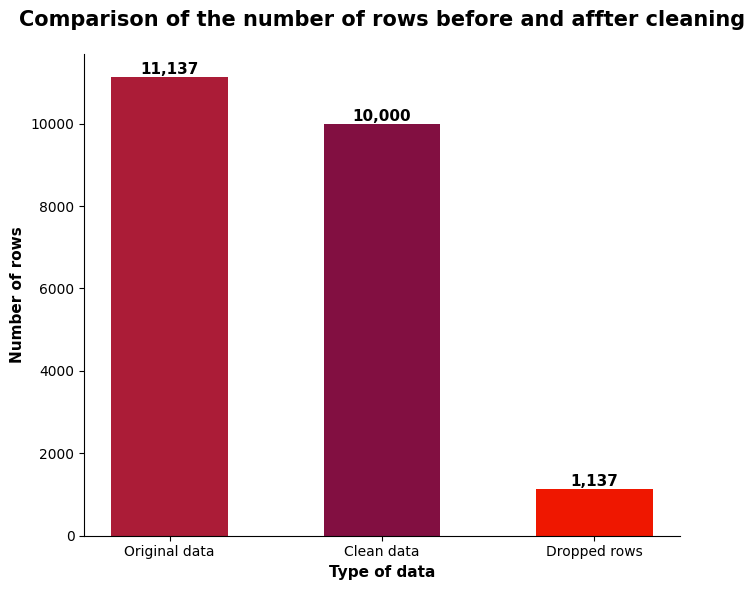

In [36]:
nms = np.array(["Original data", "Clean data", "Dropped rows"])
frq = np.array([11137, 10000, 1137])

fig, ax = plt.subplots(figsize=(7, 6))
bars = plt.bar(nms, frq,
               color=["#AB1C37","#820F41","#EF1700"],
               width=0.55)

for bar, frequency in zip(bars, frq):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{frequency:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Comparison of the number of rows before and affter cleaning", fontsize=15, fontweight="bold", pad=20)
plt.xlabel("Type of data", fontsize=11,fontweight="bold")
plt.ylabel("Number of rows", fontsize=11,fontweight="bold")


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.savefig(
    "number_rows_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
cleaning_logs_df=cleaning_logs_df.dropna(subset=["Before"])
cleaning_logs_df=cleaning_logs_df.drop(index=5)
cleaning_logs_df

,Step,Before,After
0,Original merged rows,11137.0,10000.0
1,Original unique IDs,10000.0,10000.0
2,Missing Income values,10.0,0.0
3,Missing LoanAmt values,11.0,0.0
4,Complete duplicate rows,1132.0,0.0
6,Invalid Interest Rates,3.0,0.0
7,Negative DTI values,1.0,0.0
8,Non-positive LoanAmt,1.0,0.0
9,Gross LoanAmt errors,6.0,NaN
10,Invalid Ages,2.0,0.0


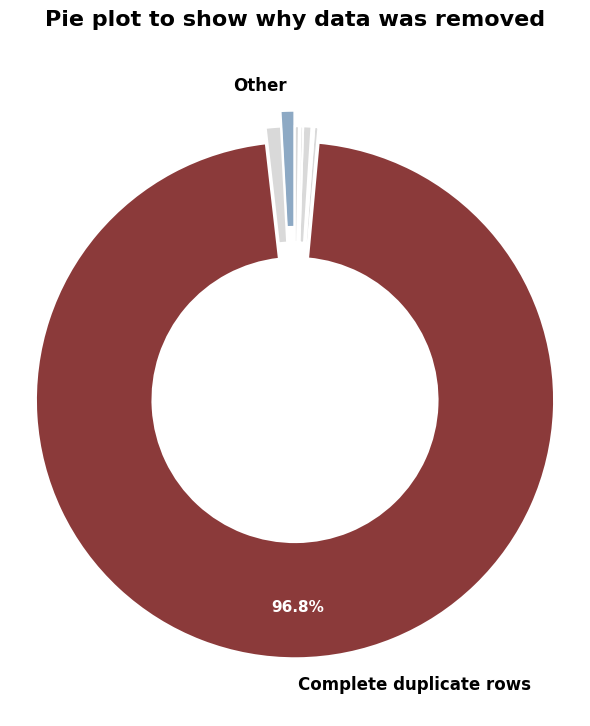

In [103]:
nrow= len(cleaning_logs_df)
labels = ["Other","", "Complete duplicate rows","","","", "", "", "", ""]
sizes = np.array(cleaning_logs_df.iloc[2:nrow+1, 1])

explode = [0.06 if lbl else 0 for lbl in labels]

colours = []
for lbl in labels:
    if lbl == "Other":
        colours.append("#8DA9C4")
    elif lbl == "Complete duplicate rows":
        colours.append("#8B3A3A")
    else:
        colours.append("#D9D9D9")

fig, ax = plt.subplots(figsize=(6,7))
ax.set_position([0.15, 0.1, 0.7, 0.7])

plt.title("Pie plot to show why data was removed", fontsize=16, fontweight="bold", pad=20)
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    explode=explode,
    colors=colours,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 3 else "",  # only label wedges big enough to read
    pctdistance=0.8,
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.5),  # donut style
    textprops=dict(fontsize=11)
)

# Bold the labeled wedges' text, keep others clean
for text, lbl in zip(texts, labels):
    if lbl:
        text.set_fontweight("bold")
        text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

ax.axis("equal")
plt.tight_layout()
plt.savefig("data_removed_pie.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()